In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [2]:
import zipfile
import os

zip_path = "archive (3).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("medical_dataset")

os.listdir("medical_dataset")

['train.csv']

In [3]:
import pandas as pd

df = pd.read_csv("medical_dataset/train.csv")

df.head()

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."


In [4]:
df.shape

(16407, 3)

In [5]:
df.columns

Index(['qtype', 'Question', 'Answer'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   qtype     16407 non-null  object
 1   Question  16407 non-null  object
 2   Answer    16407 non-null  object
dtypes: object(3)
memory usage: 384.7+ KB


In [7]:
df.isnull().sum()

,0
qtype,0
Question,0
Answer,0


In [8]:
df['qtype'].value_counts()

,count
qtype,
information,4535
symptoms,2748
treatment,2442
inheritance,1446
frequency,1120
genetic changes,1087
causes,727
exams and tests,653
research,395


In [9]:
df[['qtype', 'Question', 'Answer']].head(10)

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."
5,prevention,How to prevent Lymphocytic Choriomeningitis (L...,LCMV infection can be prevented by avoiding co...
6,information,What is (are) Parasites - Cysticercosis ?,Cysticercosis is an infection caused by the la...
7,susceptibility,Who is at risk for Parasites - Cysticercosis? ?,Cysticercosis is an infection caused by the la...
8,exams and tests,How to diagnose Parasites - Cysticercosis ?,"If you think that you may have cysticercosis, ..."
9,treatment,What are the treatments for Parasites - Cystic...,Some people with cysticercosis do not need to ...


In [10]:
print("Question Type:", df.loc[0, 'qtype'])
print("Question:", df.loc[0, 'Question'])
print("Answer:", df.loc[0, 'Answer'])

Question Type: susceptibility
Question: Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?
Answer: LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.


In [11]:
df['medical_text'] = df['Question'].astype(str) + " " + df['Answer'].astype(str)

df[['qtype', 'medical_text']].head()

,qtype,medical_text
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...
4,treatment,What are the treatments for Lymphocytic Chorio...


In [12]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s\-]', '', text)
    return text.strip()

df['clean_text'] = df['medical_text'].apply(clean_text)

df[['medical_text', 'clean_text']].head()

,medical_text,clean_text
0,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...
1,What are the symptoms of Lymphocytic Choriomen...,what are the symptoms of lymphocytic choriomen...
2,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...
3,How to diagnose Lymphocytic Choriomeningitis (...,how to diagnose lymphocytic choriomeningitis l...
4,What are the treatments for Lymphocytic Chorio...,what are the treatments for lymphocytic chorio...


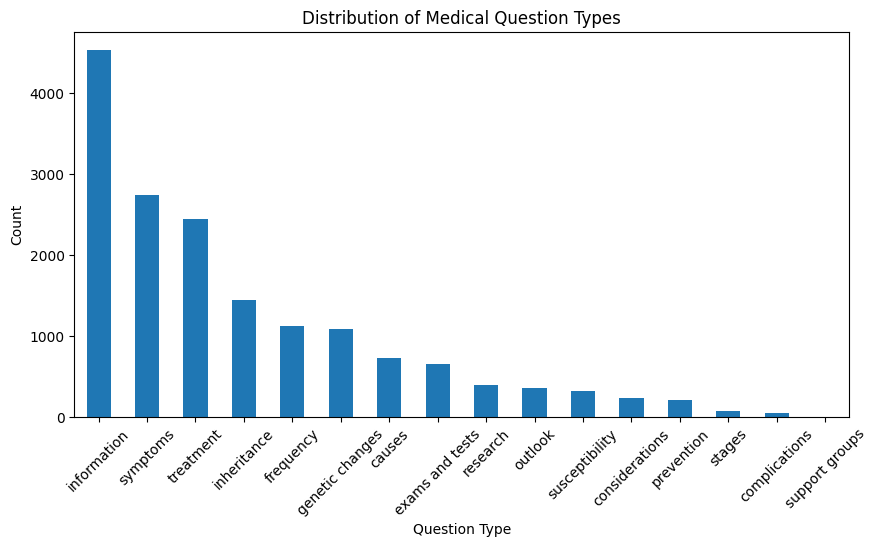

In [13]:
import matplotlib.pyplot as plt

qtype_counts = df['qtype'].value_counts()

plt.figure(figsize=(10, 5))
qtype_counts.plot(kind='bar')
plt.title("Distribution of Medical Question Types")
plt.xlabel("Question Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=30
)

word_matrix = vectorizer.fit_transform(df['clean_text'])

common_words = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_matrix.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

common_words

,word,count
21,people,21428
26,symptoms,20144
27,syndrome,15176
8,cancer,14246
12,condition,14175
5,blood,14112
13,disease,14056
25,symptom,13785
20,patients,13030
18,information,12787


In [15]:
phrase_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 3),
    max_features=30
)

phrase_matrix = phrase_vectorizer.fit_transform(df['clean_text'])

common_phrases = pd.DataFrame({
    'phrase': phrase_vectorizer.get_feature_names_out(),
    'count': phrase_matrix.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

common_phrases

,phrase,count
26,signs symptoms,11205
25,sign symptom,6732
10,human phenotype,4486
19,phenotype ontology,4486
11,human phenotype ontology,4486
4,clinical trials,4259
2,autosomal recessive,3128
16,people condition,2736
8,genetic testing,2495
1,autosomal dominant,2372


In [16]:
diagnosis_keywords = [
    'disease', 'disorder', 'condition', 'syndrome',
    'infection', 'cancer', 'diabetes', 'asthma',
    'arthritis', 'anemia', 'tumor'
]

medication_keywords = [
    'medicine', 'medication', 'drug', 'antibiotic',
    'vaccine', 'dose', 'tablet', 'injection',
    'treatment', 'therapy'
]

procedure_keywords = [
    'surgery', 'operation', 'test', 'scan',
    'x-ray', 'biopsy', 'transplant', 'screening',
    'diagnosis', 'procedure'
]

def count_keywords(text, keywords):
    return sum(1 for word in keywords if word in text)

df['diagnosis_score'] = df['clean_text'].apply(lambda x: count_keywords(x, diagnosis_keywords))
df['medication_score'] = df['clean_text'].apply(lambda x: count_keywords(x, medication_keywords))
df['procedure_score'] = df['clean_text'].apply(lambda x: count_keywords(x, procedure_keywords))

df[['Question', 'diagnosis_score', 'medication_score', 'procedure_score']].head()

,Question,diagnosis_score,medication_score,procedure_score
0,Who is at risk for Lymphocytic Choriomeningiti...,1,0,1
1,What are the symptoms of Lymphocytic Choriomen...,3,0,1
2,Who is at risk for Lymphocytic Choriomeningiti...,1,0,1
3,How to diagnose Lymphocytic Choriomeningitis (...,1,0,1
4,What are the treatments for Lymphocytic Chorio...,1,2,0


In [17]:
medication_records = df[df['medication_score'] > 0]

medication_records[['qtype', 'Question', 'Answer']].head(10)

,qtype,Question,Answer
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."
9,treatment,What are the treatments for Parasites - Cystic...,Some people with cysticercosis do not need to ...
10,prevention,How to prevent Parasites - Cysticercosis ?,"To prevent cysticercosis, the following precau..."
14,treatment,What are the treatments for Parasites - Trichu...,Anthelminthic medications (drugs that rid the ...
17,exams and tests,how can these diseases be diagnosed for Marine...,Diagnosis of marine toxin poisoning is general...
18,treatment,how can these diseases be treated for Marine T...,Other than supportive care there are few speci...
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...
27,treatment,What are the treatments for Parasites - Schist...,Safe and effective medication is available for...
28,prevention,How to prevent Parasites - Schistosomiasis ?,Prevention\n \nNo vaccine is available.\n ...
32,treatment,What are the treatments for Parasites - Lice -...,General Guidelines \n \nTreatment for head l...


In [18]:
procedure_records = df[df['procedure_score'] > 0]

procedure_records[['qtype', 'Question', 'Answer']].head(10)

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
5,prevention,How to prevent Lymphocytic Choriomeningitis (L...,LCMV infection can be prevented by avoiding co...
7,susceptibility,Who is at risk for Parasites - Cysticercosis? ?,Cysticercosis is an infection caused by the la...
8,exams and tests,How to diagnose Parasites - Cysticercosis ?,"If you think that you may have cysticercosis, ..."
9,treatment,What are the treatments for Parasites - Cystic...,Some people with cysticercosis do not need to ...
11,information,What is (are) Parasites - Trichuriasis (also k...,Whipworm (Trichuris trichiura) is an intestina...
13,exams and tests,How to diagnose Parasites - Trichuriasis (also...,The standard method for diagnosing the presenc...


In [19]:
diagnosis_records = df[df['diagnosis_score'] > 0]

diagnosis_records[['qtype', 'Question', 'Answer']].head(10)

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."
5,prevention,How to prevent Lymphocytic Choriomeningitis (L...,LCMV infection can be prevented by avoiding co...
6,information,What is (are) Parasites - Cysticercosis ?,Cysticercosis is an infection caused by the la...
7,susceptibility,Who is at risk for Parasites - Cysticercosis? ?,Cysticercosis is an infection caused by the la...
8,exams and tests,How to diagnose Parasites - Cysticercosis ?,"If you think that you may have cysticercosis, ..."
10,prevention,How to prevent Parasites - Cysticercosis ?,"To prevent cysticercosis, the following precau..."


In [20]:
pattern_counts = {
    'Diagnosis Related': (df['diagnosis_score'] > 0).sum(),
    'Medication Related': (df['medication_score'] > 0).sum(),
    'Procedure Related': (df['procedure_score'] > 0).sum()
}

pattern_df = pd.DataFrame(
    pattern_counts.items(),
    columns=['Category', 'Count']
)

pattern_df

,Category,Count
0,Diagnosis Related,14681
1,Medication Related,5990
2,Procedure Related,5295


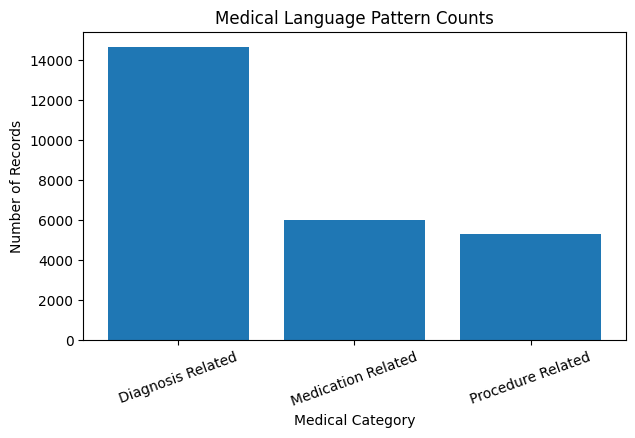

In [21]:
plt.figure(figsize=(7, 4))
plt.bar(pattern_df['Category'], pattern_df['Count'])
plt.title("Medical Language Pattern Counts")
plt.xlabel("Medical Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.show()

In [22]:
df.to_csv("prepared_medical_text_dataset.csv", index=False)

files.download("prepared_medical_text_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("medical_dataset/train.csv")

df.head()

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."


In [25]:
df.shape

(16407, 3)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   qtype     16407 non-null  object
 1   Question  16407 non-null  object
 2   Answer    16407 non-null  object
dtypes: object(3)
memory usage: 384.7+ KB


In [27]:
df.describe(include='all')

,qtype,Question,Answer
count,16407,16407,16407
unique,16,14979,15817
top,information,What causes Causes of Diabetes ?,This condition is inherited in an autosomal re...
freq,4535,20,348


In [28]:
df.columns

Index(['qtype', 'Question', 'Answer'], dtype='object')

In [29]:
df.isnull().sum()

,0
qtype,0
Question,0
Answer,0


In [30]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

,0
qtype,0.0
Question,0.0
Answer,0.0


In [31]:
df['qtype'] = df['qtype'].fillna("unknown")
df['Question'] = df['Question'].fillna("")
df['Answer'] = df['Answer'].fillna("")

In [32]:
df.duplicated().sum()

np.int64(48)

In [33]:
duplicates = df[df.duplicated()]
duplicates.head()

,qtype,Question,Answer
1388,information,What is (are) Hypoglycemia ?,"Hypoglycemia, also called low blood glucose or..."
1390,symptoms,What are the symptoms of Hypoglycemia ?,Hypoglycemia causes symptoms such as\n ...
1392,causes,What causes Hypoglycemia ?,Diabetes Medications\n \nHypogl...
1395,treatment,What are the treatments for Hypoglycemia ?,Signs and symptoms of hypoglycemia vary from p...
1596,treatment,What are the treatments for Acromegaly ?,"Currently, treatment options include surgical ..."


In [34]:
df = df.drop_duplicates()

df.shape

(16359, 3)

In [35]:
df['qtype'].value_counts()

,count
qtype,
information,4520
symptoms,2747
treatment,2440
inheritance,1446
frequency,1120
genetic changes,1087
causes,708
exams and tests,650
research,395


In [36]:
df['qtype'] = df['qtype'].astype(str).str.lower().str.strip()

df['qtype'].value_counts()

,count
qtype,
information,4520
symptoms,2747
treatment,2440
inheritance,1446
frequency,1120
genetic changes,1087
causes,708
exams and tests,650
research,395


In [37]:
empty_questions = df[df['Question'].str.strip() == ""]
empty_answers = df[df['Answer'].str.strip() == ""]

print("Empty Questions:", len(empty_questions))
print("Empty Answers:", len(empty_answers))

Empty Questions: 0
Empty Answers: 0


In [38]:
df = df[~((df['Question'].str.strip() == "") & (df['Answer'].str.strip() == ""))]

df.shape

(16359, 3)

In [39]:
df['medical_text'] = df['Question'].astype(str) + " " + df['Answer'].astype(str)

df[['qtype', 'medical_text']].head()

,qtype,medical_text
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...
4,treatment,What are the treatments for Lymphocytic Chorio...


In [40]:
df['clean_text'] = df['medical_text'].str.lower()

df[['medical_text', 'clean_text']].head()

,medical_text,clean_text
0,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...
1,What are the symptoms of Lymphocytic Choriomen...,what are the symptoms of lymphocytic choriomen...
2,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...
3,How to diagnose Lymphocytic Choriomeningitis (...,how to diagnose lymphocytic choriomeningitis (...
4,What are the treatments for Lymphocytic Chorio...,what are the treatments for lymphocytic chorio...


In [41]:
def remove_unwanted_characters(text):
    text = str(text)
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-z0-9\s\-\/]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['clean_text'].apply(remove_unwanted_characters)

df[['clean_text']].head()

,clean_text
0,who is at risk for lymphocytic choriomeningiti...
1,what are the symptoms of lymphocytic choriomen...
2,who is at risk for lymphocytic choriomeningiti...
3,how to diagnose lymphocytic choriomeningitis l...
4,what are the treatments for lymphocytic chorio...


In [42]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [43]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

df[['clean_text', 'tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,clean_text,tokens
0,who is at risk for lymphocytic choriomeningiti...,"[who, is, at, risk, for, lymphocytic, choriome..."
1,what are the symptoms of lymphocytic choriomen...,"[what, are, the, symptoms, of, lymphocytic, ch..."
2,who is at risk for lymphocytic choriomeningiti...,"[who, is, at, risk, for, lymphocytic, choriome..."
3,how to diagnose lymphocytic choriomeningitis l...,"[how, to, diagnose, lymphocytic, choriomeningi..."
4,what are the treatments for lymphocytic chorio...,"[what, are, the, treatments, for, lymphocytic,..."


In [44]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

clinical_terms_to_keep = {
    'pain', 'fever', 'cancer', 'diabetes', 'infection',
    'disease', 'syndrome', 'blood', 'heart', 'brain',
    'lung', 'kidney', 'liver', 'therapy', 'treatment',
    'surgery', 'dose', 'drug', 'vaccine', 'virus',
    'symptom', 'diagnosis', 'test', 'scan'
}

custom_stop_words = stop_words - clinical_terms_to_keep

def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in custom_stop_words and len(word) > 1
    ]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

df[['tokens', 'tokens_no_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokens,tokens_no_stopwords
0,"[who, is, at, risk, for, lymphocytic, choriome...","[risk, lymphocytic, choriomeningitis, lcm, lcm..."
1,"[what, are, the, symptoms, of, lymphocytic, ch...","[symptoms, lymphocytic, choriomeningitis, lcm,..."
2,"[who, is, at, risk, for, lymphocytic, choriome...","[risk, lymphocytic, choriomeningitis, lcm, ind..."
3,"[how, to, diagnose, lymphocytic, choriomeningi...","[diagnose, lymphocytic, choriomeningitis, lcm,..."
4,"[what, are, the, treatments, for, lymphocytic,...","[treatments, lymphocytic, choriomeningitis, lc..."


In [45]:
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def normalize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['normalized_tokens'] = df['tokens_no_stopwords'].apply(normalize_tokens)

df[['tokens_no_stopwords', 'normalized_tokens']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,tokens_no_stopwords,normalized_tokens
0,"[risk, lymphocytic, choriomeningitis, lcm, lcm...","[risk, lymphocytic, choriomeningitis, lcm, lcm..."
1,"[symptoms, lymphocytic, choriomeningitis, lcm,...","[symptom, lymphocytic, choriomeningitis, lcm, ..."
2,"[risk, lymphocytic, choriomeningitis, lcm, ind...","[risk, lymphocytic, choriomeningitis, lcm, ind..."
3,"[diagnose, lymphocytic, choriomeningitis, lcm,...","[diagnose, lymphocytic, choriomeningitis, lcm,..."
4,"[treatments, lymphocytic, choriomeningitis, lc...","[treatment, lymphocytic, choriomeningitis, lcm..."


In [46]:
df['preprocessed_text'] = df['normalized_tokens'].apply(lambda tokens: " ".join(tokens))

df[['medical_text', 'preprocessed_text']].head()

,medical_text,preprocessed_text
0,Who is at risk for Lymphocytic Choriomeningiti...,risk lymphocytic choriomeningitis lcm lcmv inf...
1,What are the symptoms of Lymphocytic Choriomen...,symptom lymphocytic choriomeningitis lcm lcmv ...
2,Who is at risk for Lymphocytic Choriomeningiti...,risk lymphocytic choriomeningitis lcm individu...
3,How to diagnose Lymphocytic Choriomeningitis (...,diagnose lymphocytic choriomeningitis lcm firs...
4,What are the treatments for Lymphocytic Chorio...,treatment lymphocytic choriomeningitis lcm ase...


In [47]:
from collections import Counter

all_words = []

for tokens in df['normalized_tokens']:
    all_words.extend(tokens)

word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(
    word_freq.items(),
    columns=['word', 'frequency']
).sort_values(by='frequency', ascending=False)

word_freq_df.head(30)

,word,frequency
38,symptom,33893
17,may,28303
454,people,21293
1420,sign,19733
437,condition,16973
263,treatment,16943
43,disease,15475
2189,syndrome,15367
1493,cancer,14761
234,cell,14750


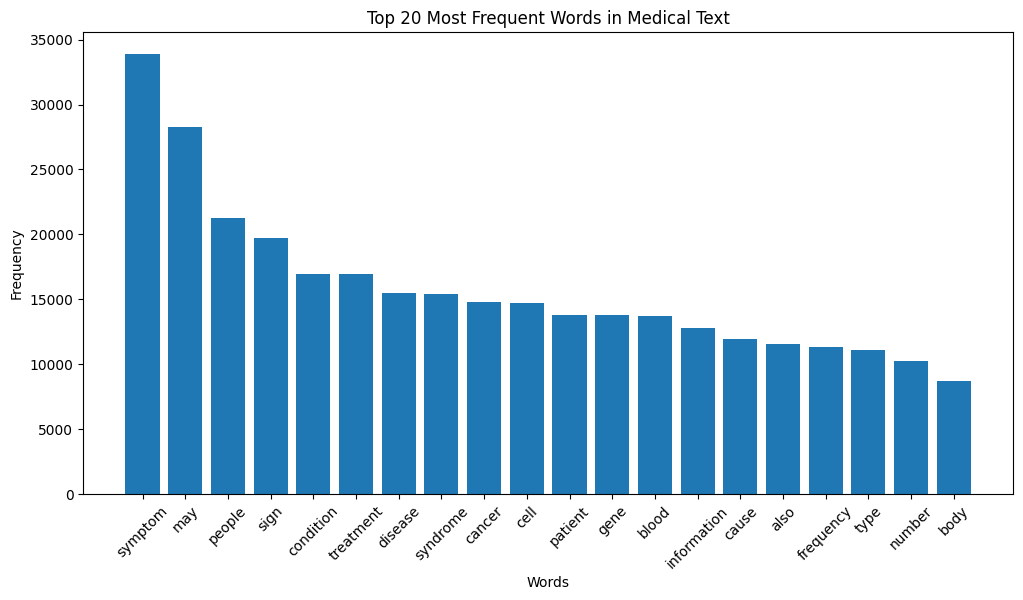

In [48]:
top_words = word_freq_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_words['word'], top_words['frequency'])
plt.title("Top 20 Most Frequent Words in Medical Text")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [49]:
df.to_csv("cleaned_medical_text_dataset.csv", index=False)

In [50]:
from google.colab import files

files.download("cleaned_medical_text_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [52]:
df = pd.read_csv("cleaned_medical_text_dataset.csv")

df.head()

,qtype,Question,Answer,medical_text,clean_text,tokens,tokens_no_stopwords,normalized_tokens,preprocessed_text
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...,"['who', 'is', 'at', 'risk', 'for', 'lymphocyti...","['risk', 'lymphocytic', 'choriomeningitis', 'l...","['risk', 'lymphocytic', 'choriomeningitis', 'l...",risk lymphocytic choriomeningitis lcm lcmv inf...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,What are the symptoms of Lymphocytic Choriomen...,what are the symptoms of lymphocytic choriomen...,"['what', 'are', 'the', 'symptoms', 'of', 'lymp...","['symptoms', 'lymphocytic', 'choriomeningitis'...","['symptom', 'lymphocytic', 'choriomeningitis',...",symptom lymphocytic choriomeningitis lcm lcmv ...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...,"['who', 'is', 'at', 'risk', 'for', 'lymphocyti...","['risk', 'lymphocytic', 'choriomeningitis', 'l...","['risk', 'lymphocytic', 'choriomeningitis', 'l...",risk lymphocytic choriomeningitis lcm individu...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos...",How to diagnose Lymphocytic Choriomeningitis (...,how to diagnose lymphocytic choriomeningitis l...,"['how', 'to', 'diagnose', 'lymphocytic', 'chor...","['diagnose', 'lymphocytic', 'choriomeningitis'...","['diagnose', 'lymphocytic', 'choriomeningitis'...",diagnose lymphocytic choriomeningitis lcm firs...
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen...",What are the treatments for Lymphocytic Chorio...,what are the treatments for lymphocytic chorio...,"['what', 'are', 'the', 'treatments', 'for', 'l...","['treatments', 'lymphocytic', 'choriomeningiti...","['treatment', 'lymphocytic', 'choriomeningitis...",treatment lymphocytic choriomeningitis lcm ase...


In [53]:
df.columns

Index(['qtype', 'Question', 'Answer', 'medical_text', 'clean_text', 'tokens',
       'tokens_no_stopwords', 'normalized_tokens', 'preprocessed_text'],
      dtype='object')

In [54]:
df['preprocessed_text'] = df['preprocessed_text'].fillna("")
df['qtype'] = df['qtype'].fillna("unknown")

In [55]:
all_text = " ".join(df['preprocessed_text'].astype(str))

words = all_text.split()

print("Total words:", len(words))
print("Unique words:", len(set(words)))

Total words: 1997984
Unique words: 29882


In [56]:
all_text = " ".join(df['preprocessed_text'].astype(str))

words = all_text.split()

print("Total words:", len(words))
print("Unique words:", len(set(words)))

Total words: 1997984
Unique words: 29882


In [57]:
word_freq = Counter(words)

word_freq_df = pd.DataFrame(
    word_freq.items(),
    columns=['keyword', 'frequency']
).sort_values(by='frequency', ascending=False)

word_freq_df.head(30)

,keyword,frequency
38,symptom,33893
17,may,28303
454,people,21293
1420,sign,19733
437,condition,16973
263,treatment,16943
43,disease,15475
2189,syndrome,15367
1493,cancer,14761
234,cell,14750


In [58]:
word_freq = Counter(words)

word_freq_df = pd.DataFrame(
    word_freq.items(),
    columns=['keyword', 'frequency']
).sort_values(by='frequency', ascending=False)

word_freq_df.head(30)

,keyword,frequency
38,symptom,33893
17,may,28303
454,people,21293
1420,sign,19733
437,condition,16973
263,treatment,16943
43,disease,15475
2189,syndrome,15367
1493,cancer,14761
234,cell,14750


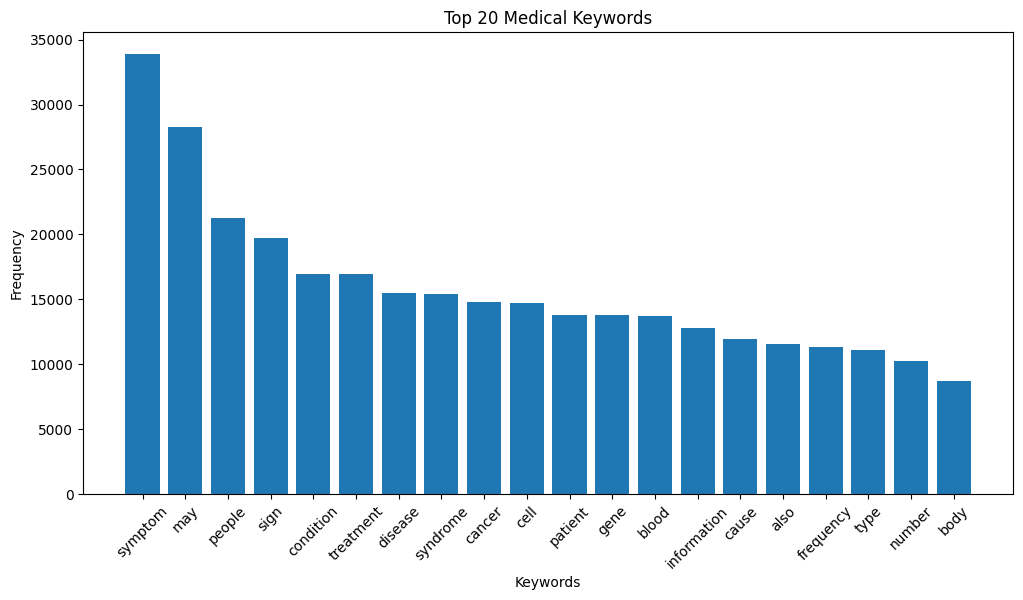

In [59]:
top_keywords = word_freq_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_keywords['keyword'], top_keywords['frequency'])
plt.title("Top 20 Medical Keywords")
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

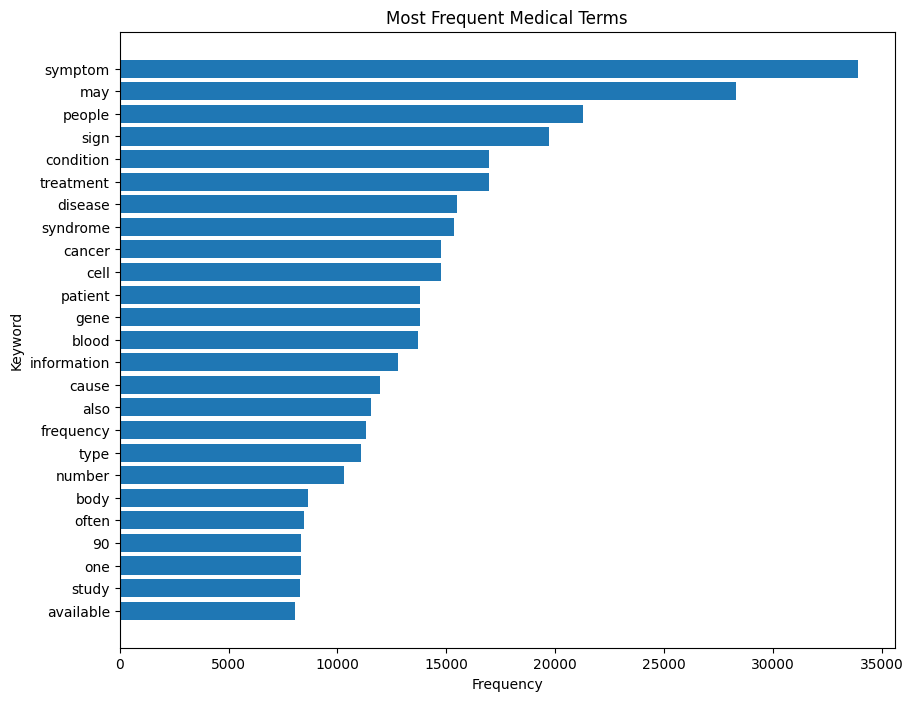

In [60]:
top_keywords = word_freq_df.head(25)

plt.figure(figsize=(10, 8))
plt.barh(top_keywords['keyword'], top_keywords['frequency'])
plt.title("Most Frequent Medical Terms")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.gca().invert_yaxis()
plt.show()

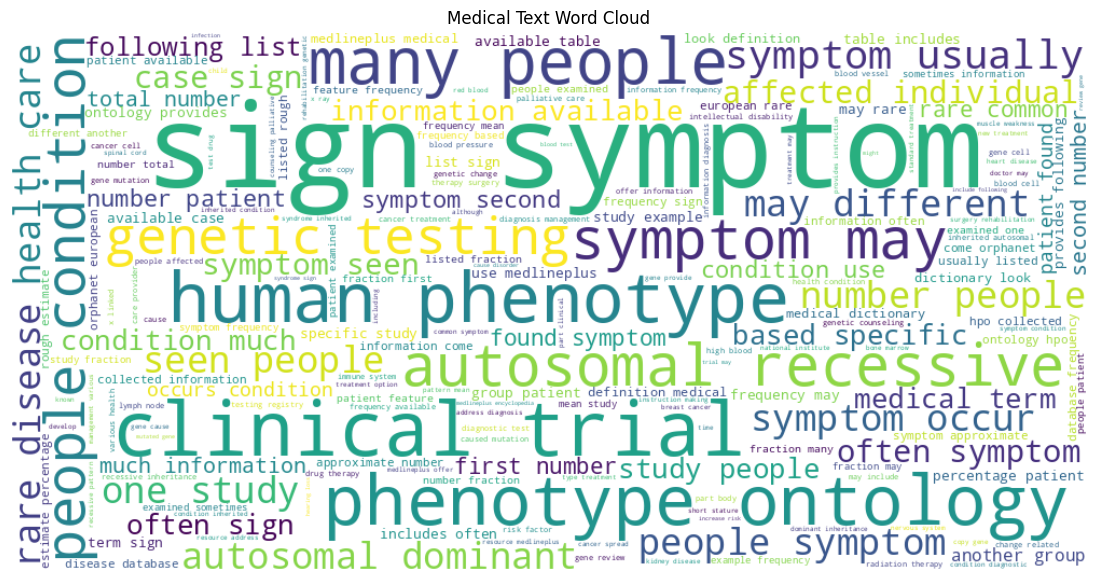

In [61]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Medical Text Word Cloud")
plt.show()

In [62]:
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    max_features=40
)

ngram_matrix = vectorizer.fit_transform(df['preprocessed_text'])

ngram_freq = pd.DataFrame({
    'phrase': vectorizer.get_feature_names_out(),
    'frequency': ngram_matrix.sum(axis=0).A1
}).sort_values(by='frequency', ascending=False)

ngram_freq.head(30)

,phrase,frequency
32,sign symptom,17939
6,clinical trial,5415
13,human phenotype ontology,4486
28,phenotype ontology,4486
12,human phenotype,4486
17,may also,3932
15,many people,3816
2,autosomal recessive,3128
35,symptom may,2975
26,people condition,2741


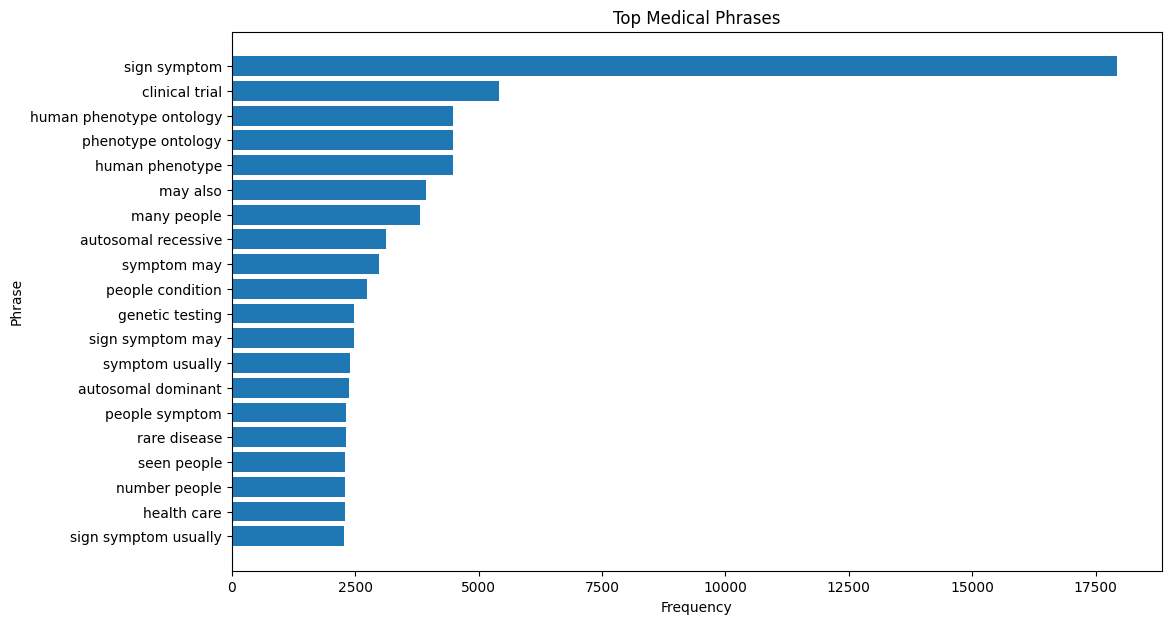

In [63]:
top_phrases = ngram_freq.head(20)

plt.figure(figsize=(12, 7))
plt.barh(top_phrases['phrase'], top_phrases['frequency'])
plt.title("Top Medical Phrases")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.gca().invert_yaxis()
plt.show()

In [64]:
healthcare_entities = {
    "Symptoms": [
        "pain", "fever", "cough", "headache", "fatigue", "nausea",
        "vomiting", "rash", "swelling", "weakness", "dizziness"
    ],
    "Diseases": [
        "cancer", "diabetes", "asthma", "infection", "arthritis",
        "anemia", "syndrome", "tumor", "hypertension", "hepatitis"
    ],
    "Treatments": [
        "treatment", "therapy", "surgery", "medicine", "medication",
        "drug", "antibiotic", "vaccine", "dose", "injection"
    ],
    "Procedures": [
        "test", "scan", "biopsy", "screening", "diagnosis",
        "x-ray", "transplant", "operation", "examination"
    ],
    "Body Parts": [
        "heart", "brain", "lung", "kidney", "liver", "blood",
        "skin", "bone", "eye", "ear", "stomach"
    ]
}

In [65]:
entity_counts = {}

for category, terms in healthcare_entities.items():
    count = 0
    for term in terms:
        count += word_freq.get(term, 0)
    entity_counts[category] = count

entity_df = pd.DataFrame(
    entity_counts.items(),
    columns=['Entity Type', 'Frequency']
).sort_values(by='Frequency', ascending=False)

entity_df

,Entity Type,Frequency
4,Body Parts,50787
1,Diseases,46540
2,Treatments,38170
3,Procedures,15144
0,Symptoms,9778


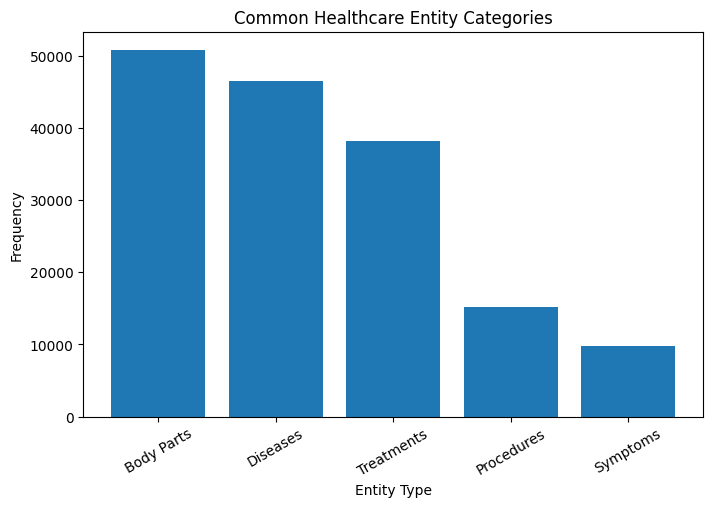

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(entity_df['Entity Type'], entity_df['Frequency'])
plt.title("Common Healthcare Entity Categories")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.xticks(rotation=30)
plt.show()

In [67]:
symptom_terms = healthcare_entities["Symptoms"]

symptom_pattern = "|".join(symptom_terms)

symptom_records = df[df['preprocessed_text'].str.contains(symptom_pattern, case=False, na=False)]

symptom_records[['qtype', 'Question', 'Answer']].head(10)

,qtype,Question,Answer
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...
35,susceptibility,Who is at risk for Parasites - Lice - Body Lic...,Body lice infestation is found worldwide but g...
41,susceptibility,Who is at risk for Parasites - Toxocariasis (a...,Infected dogs and cats shed Toxocara eggs in t...
44,prevention,How to prevent Parasites - Toxocariasis (also ...,Controlling Toxocara infection in dogs and cat...
50,information,What is (are) Parasites - Scabies ?,Scabies is an infestation of the skin by the h...
52,exams and tests,How to diagnose Parasites - Scabies ?,Diagnosis of a scabies infestation usually is ...
53,treatment,What are the treatments for Parasites - Scabies ?,Suggested General Guidelines \n \n \n \n...
55,susceptibility,Who is at risk for Alkhurma Hemorrhagic Fever ...,Transmission of AHFV is not well understood. A...
56,symptoms,What are the symptoms of Alkhurma Hemorrhagic ...,"Based on limited information, after an incubat..."


In [68]:
treatment_terms = healthcare_entities["Treatments"]

treatment_pattern = "|".join(treatment_terms)

treatment_records = df[df['preprocessed_text'].str.contains(treatment_pattern, case=False, na=False)]

treatment_records[['qtype', 'Question', 'Answer']].head(10)

,qtype,Question,Answer
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."
9,treatment,What are the treatments for Parasites - Cystic...,Some people with cysticercosis do not need to ...
14,treatment,What are the treatments for Parasites - Trichu...,Anthelminthic medications (drugs that rid the ...
17,exams and tests,how can these diseases be diagnosed for Marine...,Diagnosis of marine toxin poisoning is general...
18,treatment,how can these diseases be treated for Marine T...,Other than supportive care there are few speci...
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...
27,treatment,What are the treatments for Parasites - Schist...,Safe and effective medication is available for...
28,prevention,How to prevent Parasites - Schistosomiasis ?,Prevention\n \nNo vaccine is available.\n ...
32,treatment,What are the treatments for Parasites - Lice -...,General Guidelines \n \nTreatment for head l...
33,prevention,How to prevent Parasites - Lice - Head Lice ?,Head lice are spread most commonly by direct h...


In [69]:
X = df['preprocessed_text']
y = df['qtype']

In [70]:
df['qtype'].value_counts().tail(20)

,count
qtype,
information,4520
symptoms,2747
treatment,2440
inheritance,1446
frequency,1120
genetic changes,1087
causes,708
exams and tests,650
research,395


In [71]:
from sklearn.model_selection import train_test_split

X = df['preprocessed_text']
y = df['qtype']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 13087
Testing records: 3272


In [72]:
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})

test_df = pd.DataFrame({
    'text': X_test,
    'label': y_test
})

train_df.head()

,text,label
12826,symptom chondrosarcoma sign symptom chondrosar...,symptoms
10835,myotonia congenita myotonia congenita disorder...,information
11100,autoimmune pancreatitis autoimmune pancreatiti...,information
6518,intrahepatic cholestasis pregnancy inherited s...,inheritance
5908,autosomal dominant vitreoretinochoroidopathy i...,inheritance


In [73]:
train_df.to_csv("medical_train_dataset.csv", index=False)
test_df.to_csv("medical_test_dataset.csv", index=False)

In [74]:
from google.colab import files

files.download("medical_train_dataset.csv")
files.download("medical_test_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
summary = {
    "Total Records": len(df),
    "Unique Question Types": df['qtype'].nunique(),
    "Total Words": len(words),
    "Unique Words": len(set(words)),
    "Training Records": len(train_df),
    "Testing Records": len(test_df)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

summary_df

,Metric,Value
0,Total Records,16359
1,Unique Question Types,16
2,Total Words,1997984
3,Unique Words,29882
4,Training Records,13087
5,Testing Records,3272


In [76]:
!pip install rake-nltk keybert sentence-transformers spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.9 MB/s eta 0:00:00


In [77]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from rake_nltk import Rake
from keybert import KeyBERT

In [78]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [79]:
df = pd.read_csv("cleaned_medical_text_dataset.csv")

df.head()

,qtype,Question,Answer,medical_text,clean_text,tokens,tokens_no_stopwords,normalized_tokens,preprocessed_text
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...,"['who', 'is', 'at', 'risk', 'for', 'lymphocyti...","['risk', 'lymphocytic', 'choriomeningitis', 'l...","['risk', 'lymphocytic', 'choriomeningitis', 'l...",risk lymphocytic choriomeningitis lcm lcmv inf...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,What are the symptoms of Lymphocytic Choriomen...,what are the symptoms of lymphocytic choriomen...,"['what', 'are', 'the', 'symptoms', 'of', 'lymp...","['symptoms', 'lymphocytic', 'choriomeningitis'...","['symptom', 'lymphocytic', 'choriomeningitis',...",symptom lymphocytic choriomeningitis lcm lcmv ...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...,Who is at risk for Lymphocytic Choriomeningiti...,who is at risk for lymphocytic choriomeningiti...,"['who', 'is', 'at', 'risk', 'for', 'lymphocyti...","['risk', 'lymphocytic', 'choriomeningitis', 'l...","['risk', 'lymphocytic', 'choriomeningitis', 'l...",risk lymphocytic choriomeningitis lcm individu...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos...",How to diagnose Lymphocytic Choriomeningitis (...,how to diagnose lymphocytic choriomeningitis l...,"['how', 'to', 'diagnose', 'lymphocytic', 'chor...","['diagnose', 'lymphocytic', 'choriomeningitis'...","['diagnose', 'lymphocytic', 'choriomeningitis'...",diagnose lymphocytic choriomeningitis lcm firs...
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen...",What are the treatments for Lymphocytic Chorio...,what are the treatments for lymphocytic chorio...,"['what', 'are', 'the', 'treatments', 'for', 'l...","['treatments', 'lymphocytic', 'choriomeningiti...","['treatment', 'lymphocytic', 'choriomeningitis...",treatment lymphocytic choriomeningitis lcm ase...


In [80]:
df.columns

Index(['qtype', 'Question', 'Answer', 'medical_text', 'clean_text', 'tokens',
       'tokens_no_stopwords', 'normalized_tokens', 'preprocessed_text'],
      dtype='object')

In [81]:
df['preprocessed_text'] = df['preprocessed_text'].fillna("")
df['Question'] = df['Question'].fillna("")
df['Answer'] = df['Answer'].fillna("")
df['qtype'] = df['qtype'].fillna("unknown")

In [82]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1, 3)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['preprocessed_text'])

tfidf_features = tfidf_vectorizer.get_feature_names_out()

In [83]:
def extract_tfidf_keywords(row_index, top_n=10):
    row = tfidf_matrix[row_index].toarray().flatten()
    top_indices = row.argsort()[-top_n:][::-1]

    keywords = [
        tfidf_features[i]
        for i in top_indices
        if row[i] > 0
    ]

    return keywords

In [84]:
df['tfidf_keywords'] = [
    extract_tfidf_keywords(i, top_n=10)
    for i in range(len(df))
]

df[['Question', 'tfidf_keywords']].head()

,Question,tfidf_keywords
0,Who is at risk for Lymphocytic Choriomeningiti...,"[infected, material, person, occur, exposure, ..."
1,What are the symptoms of Lymphocytic Choriomen...,"[illness, infection, infected, pregnancy, pain..."
2,Who is at risk for Lymphocytic Choriomeningiti...,"[risk, infected, laboratory, infection, virus,..."
3,How to diagnose Lymphocytic Choriomeningitis (...,"[white blood, white blood cell, laboratory, vi..."
4,What are the treatments for Lymphocytic Chorio...,"[treatment, drug, used treat, inflammatory, co..."


In [85]:
rake = Rake()

def extract_rake_keywords(text, top_n=10):
    rake.extract_keywords_from_text(str(text))
    keywords = rake.get_ranked_phrases()[:top_n]
    return keywords

In [86]:
df['rake_keywords'] = df['medical_text'].apply(
    lambda x: extract_rake_keywords(x, top_n=10)
)

df[['Question', 'rake_keywords']].head()

,Question,rake_keywords
0,Who is at risk for Lymphocytic Choriomeningiti...,"[transmission may also occur, vertical transmi..."
1,What are the symptoms of Lymphocytic Choriomen...,[symptoms appearing less frequently include so...
2,Who is at risk for Lymphocytic Choriomeningiti...,"[wearing proper protective laboratory gear, fo..."
3,How to diagnose Lymphocytic Choriomeningitis (...,"[low white blood cell count, white blood cells..."
4,What are the treatments for Lymphocytic Chorio...,"[meningoencephalitis requires hospitalization,..."


In [87]:
kw_model = KeyBERT()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [88]:
sample_text = df.loc[0, 'medical_text']

kw_model.extract_keywords(
    sample_text,
    keyphrase_ngram_range=(1, 3),
    stop_words='english',
    top_n=10
)

[('lymphocytic choriomeningitis lcm', 0.6701),
 ('risk lymphocytic choriomeningitis', 0.6603),
 ('lcmv infections occur', 0.6514),
 ('choriomeningitis lcm lcmv', 0.6472),
 ('lcmv infections', 0.6311),
 ('lcm lcmv infections', 0.6204),
 ('choriomeningitis lcm', 0.6174),
 ('infected rodents transmission', 0.5953),
 ('lymphocytic choriomeningitis', 0.5937),
 ('risk lymphocytic', 0.5693)]

In [89]:
def extract_keybert_keywords(text, top_n=8):
    try:
        keywords = kw_model.extract_keywords(
            str(text),
            keyphrase_ngram_range=(1, 3),
            stop_words='english',
            top_n=top_n
        )
        return [word for word, score in keywords]
    except:
        return []

In [90]:
df_sample = df.head(500).copy()

df_sample['keybert_keywords'] = df_sample['medical_text'].apply(
    lambda x: extract_keybert_keywords(x, top_n=8)
)

df_sample[['Question', 'keybert_keywords']].head()

,Question,keybert_keywords
0,Who is at risk for Lymphocytic Choriomeningiti...,"[lymphocytic choriomeningitis lcm, risk lympho..."
1,What are the symptoms of Lymphocytic Choriomen...,"[symptoms lymphocytic choriomeningitis, lympho..."
2,Who is at risk for Lymphocytic Choriomeningiti...,"[risk lymphocytic choriomeningitis, lymphocyti..."
3,How to diagnose Lymphocytic Choriomeningitis (...,"[lymphocytic choriomeningitis lcm, diagnose ly..."
4,What are the treatments for Lymphocytic Chorio...,"[treatments lymphocytic choriomeningitis, lymp..."


In [91]:
df_sample.to_csv("keybert_sample_keywords.csv", index=False)

In [92]:
medical_entities = {
    "DISEASE": [
        "cancer", "diabetes", "asthma", "arthritis", "infection",
        "hypertension", "hepatitis", "anemia", "tumor", "syndrome",
        "flu", "pneumonia", "malaria", "tuberculosis"
    ],
    "SYMPTOM": [
        "fever", "pain", "cough", "headache", "fatigue",
        "nausea", "vomiting", "rash", "swelling", "dizziness",
        "weakness", "sore throat", "chest pain", "joint pain"
    ],
    "MEDICATION": [
        "drug", "medicine", "medication", "antibiotic", "vaccine",
        "insulin", "aspirin", "ibuprofen", "paracetamol",
        "dose", "tablet", "injection"
    ],
    "PROCEDURE": [
        "surgery", "biopsy", "scan", "x-ray", "screening",
        "transplant", "operation", "examination", "therapy",
        "radiation therapy", "chemotherapy"
    ],
    "LAB_TEST": [
        "blood test", "urine test", "ct scan", "mri",
        "x-ray", "biopsy", "glucose test", "cholesterol test",
        "genetic test", "screening test"
    ]
}

In [93]:
nlp = spacy.blank("en")

ruler = nlp.add_pipe("entity_ruler")

patterns = []

for label, terms in medical_entities.items():
    for term in terms:
        patterns.append({
            "label": label,
            "pattern": term
        })

ruler.add_patterns(patterns)

In [94]:
text = df.loc[0, 'medical_text']
doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)

In [95]:
def extract_medical_entities(text):
    doc = nlp(str(text).lower())

    entities = {
        "DISEASE": [],
        "SYMPTOM": [],
        "MEDICATION": [],
        "PROCEDURE": [],
        "LAB_TEST": []
    }

    for ent in doc.ents:
        entities[ent.label_].append(ent.text)

    for label in entities:
        entities[label] = list(set(entities[label]))

    return entities

In [96]:
df['medical_entities'] = df['medical_text'].apply(extract_medical_entities)

df[['Question', 'medical_entities']].head()

,Question,medical_entities
0,Who is at risk for Lymphocytic Choriomeningiti...,"{'DISEASE': [], 'SYMPTOM': [], 'MEDICATION': [..."
1,What are the symptoms of Lymphocytic Choriomen...,"{'DISEASE': ['infection', 'arthritis', 'flu'],..."
2,Who is at risk for Lymphocytic Choriomeningiti...,"{'DISEASE': ['infection'], 'SYMPTOM': [], 'MED..."
3,How to diagnose Lymphocytic Choriomeningitis (...,"{'DISEASE': [], 'SYMPTOM': [], 'MEDICATION': [..."
4,What are the treatments for Lymphocytic Chorio...,"{'DISEASE': [], 'SYMPTOM': [], 'MEDICATION': [..."


In [97]:
df['diseases'] = df['medical_entities'].apply(lambda x: x['DISEASE'])
df['symptoms'] = df['medical_entities'].apply(lambda x: x['SYMPTOM'])
df['medications'] = df['medical_entities'].apply(lambda x: x['MEDICATION'])
df['procedures'] = df['medical_entities'].apply(lambda x: x['PROCEDURE'])
df['lab_tests'] = df['medical_entities'].apply(lambda x: x['LAB_TEST'])

df[['diseases', 'symptoms', 'medications', 'procedures', 'lab_tests']].head()

,diseases,symptoms,medications,procedures,lab_tests
0,[],[],[],[],[]
1,"[infection, arthritis, flu]","[nausea, headache, vomiting, joint pain, pain,...",[],[],[]
2,[infection],[],[],[],[]
3,[],[],[],[],[]
4,[],[],[drug],[],[]


In [98]:
from collections import Counter

def flatten_column(column):
    values = []
    for item_list in df[column]:
        values.extend(item_list)
    return values

In [99]:
disease_freq = Counter(flatten_column('diseases'))
symptom_freq = Counter(flatten_column('symptoms'))
medication_freq = Counter(flatten_column('medications'))
procedure_freq = Counter(flatten_column('procedures'))
lab_test_freq = Counter(flatten_column('lab_tests'))

In [100]:
print("Top Diseases:", disease_freq.most_common(10))
print("Top Symptoms:", symptom_freq.most_common(10))
print("Top Medications:", medication_freq.most_common(10))
print("Top Procedures:", procedure_freq.most_common(10))
print("Top Lab Tests:", lab_test_freq.most_common(10))

Top Diseases: [('syndrome', 4519), ('cancer', 1561), ('infection', 1146), ('diabetes', 891), ('tumor', 775), ('anemia', 598), ('arthritis', 349), ('hypertension', 313), ('pneumonia', 201), ('hepatitis', 158)]
Top Symptoms: [('pain', 1570), ('weakness', 1023), ('fever', 593), ('swelling', 577), ('vomiting', 532), ('fatigue', 441), ('nausea', 400), ('headache', 218), ('chest pain', 211), ('dizziness', 200)]
Top Medications: [('drug', 1558), ('medicine', 400), ('medication', 346), ('dose', 229), ('insulin', 224), ('aspirin', 129), ('injection', 122), ('vaccine', 98), ('antibiotic', 86), ('ibuprofen', 50)]
Top Procedures: [('surgery', 2428), ('therapy', 2034), ('chemotherapy', 359), ('radiation therapy', 302), ('transplant', 260), ('biopsy', 241), ('scan', 216), ('x-ray', 185), ('examination', 184), ('screening', 146)]
Top Lab Tests: [('mri', 273), ('biopsy', 216), ('blood test', 201), ('ct scan', 179), ('x-ray', 125), ('genetic test', 56), ('urine test', 16), ('screening test', 14), ('glu

In [101]:
import matplotlib.pyplot as plt

def plot_entity_frequency(counter, title):
    common_items = counter.most_common(10)

    if len(common_items) == 0:
        print("No entities found for", title)
        return

    labels = [item[0] for item in common_items]
    values = [item[1] for item in common_items]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel("Entity")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

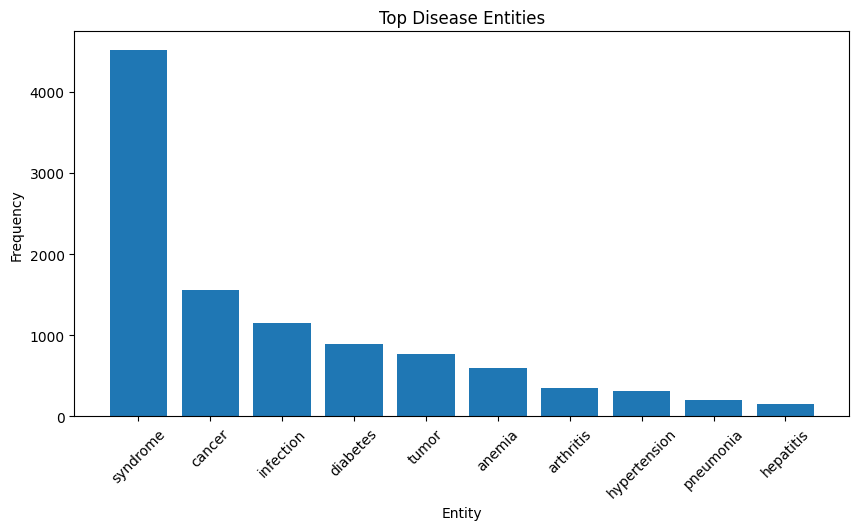

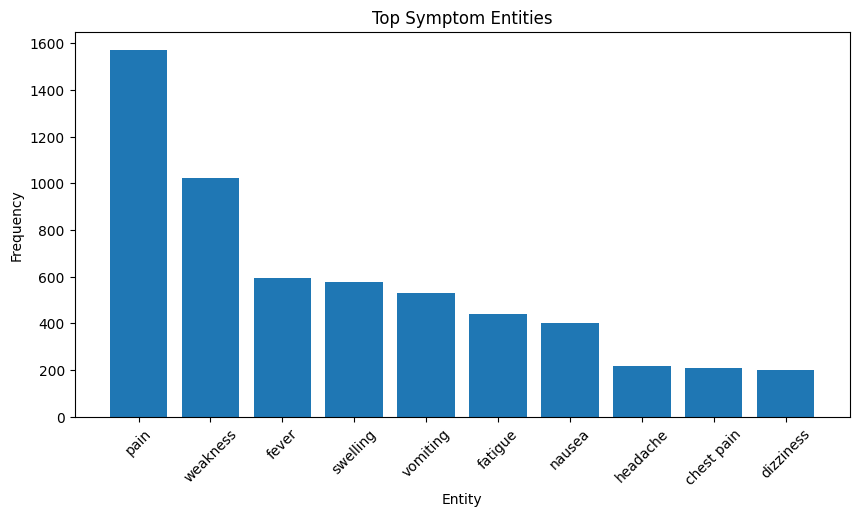

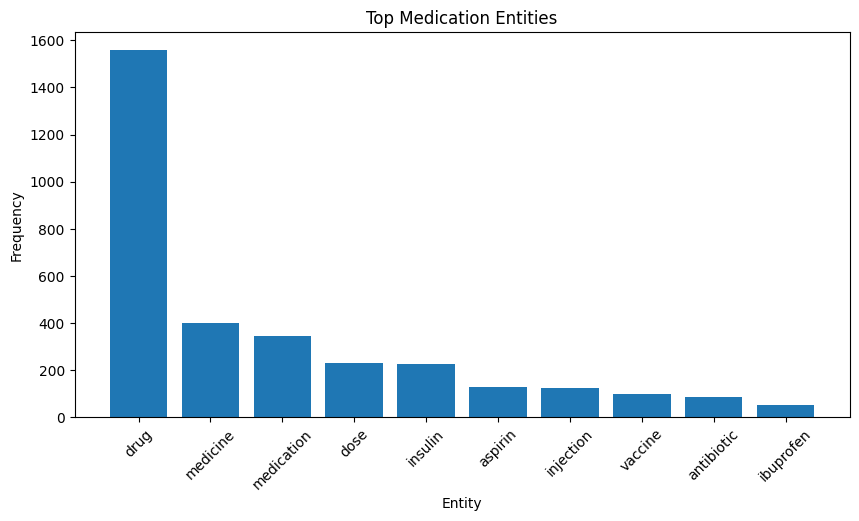

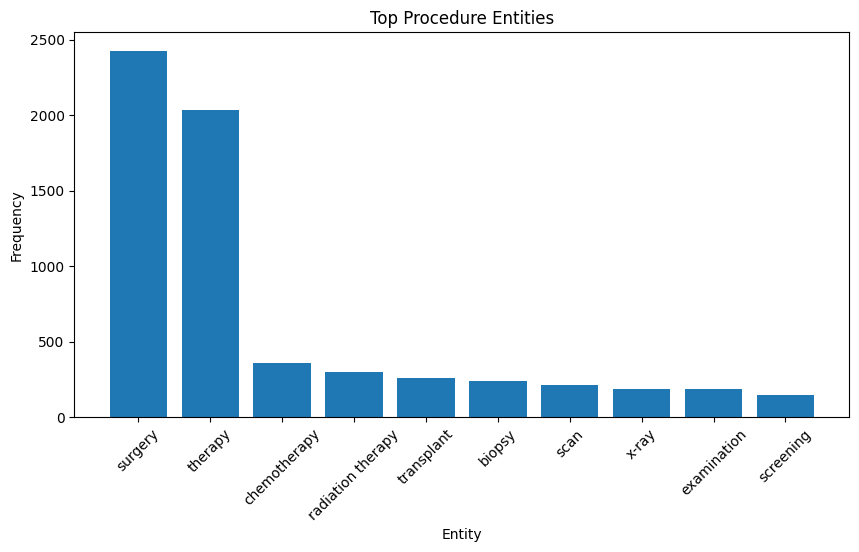

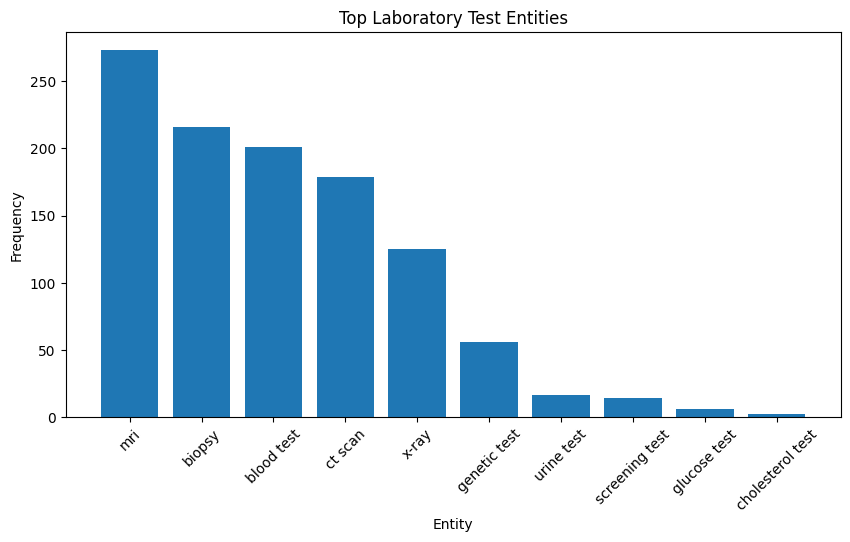

In [102]:
plot_entity_frequency(disease_freq, "Top Disease Entities")
plot_entity_frequency(symptom_freq, "Top Symptom Entities")
plot_entity_frequency(medication_freq, "Top Medication Entities")
plot_entity_frequency(procedure_freq, "Top Procedure Entities")
plot_entity_frequency(lab_test_freq, "Top Laboratory Test Entities")

In [104]:
df['keybert_keywords'] = ""

In [105]:
df.loc[df_sample.index, 'keybert_keywords'] = df_sample['keybert_keywords']

In [106]:
df[['Question', 'keybert_keywords']].head()

,Question,keybert_keywords
0,Who is at risk for Lymphocytic Choriomeningiti...,"[lymphocytic choriomeningitis lcm, risk lympho..."
1,What are the symptoms of Lymphocytic Choriomen...,"[symptoms lymphocytic choriomeningitis, lympho..."
2,Who is at risk for Lymphocytic Choriomeningiti...,"[risk lymphocytic choriomeningitis, lymphocyti..."
3,How to diagnose Lymphocytic Choriomeningitis (...,"[lymphocytic choriomeningitis lcm, diagnose ly..."
4,What are the treatments for Lymphocytic Chorio...,"[treatments lymphocytic choriomeningitis, lymp..."


In [107]:
knowledge_df = df[[
    'qtype',
    'Question',
    'Answer',
    'preprocessed_text',
    'tfidf_keywords',
    'rake_keywords',
    'keybert_keywords',
    'diseases',
    'symptoms',
    'medications',
    'procedures',
    'lab_tests'
]].copy()

knowledge_df.head()

,qtype,Question,Answer,preprocessed_text,tfidf_keywords,rake_keywords,keybert_keywords,diseases,symptoms,medications,procedures,lab_tests
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...,risk lymphocytic choriomeningitis lcm lcmv inf...,"[infected, material, person, occur, exposure, ...","[transmission may also occur, vertical transmi...","[lymphocytic choriomeningitis lcm, risk lympho...",[],[],[],[],[]
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,symptom lymphocytic choriomeningitis lcm lcmv ...,"[illness, infection, infected, pregnancy, pain...",[symptoms appearing less frequently include so...,"[symptoms lymphocytic choriomeningitis, lympho...","[infection, arthritis, flu]","[nausea, headache, vomiting, joint pain, pain,...",[],[],[]
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...,risk lymphocytic choriomeningitis lcm individu...,"[risk, infected, laboratory, infection, virus,...","[wearing proper protective laboratory gear, fo...","[risk lymphocytic choriomeningitis, lymphocyti...",[infection],[],[],[],[]
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos...",diagnose lymphocytic choriomeningitis lcm firs...,"[white blood, white blood cell, laboratory, vi...","[low white blood cell count, white blood cells...","[lymphocytic choriomeningitis lcm, diagnose ly...",[],[],[],[],[]
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen...",treatment lymphocytic choriomeningitis lcm ase...,"[treatment, drug, used treat, inflammatory, co...","[meningoencephalitis requires hospitalization,...","[treatments lymphocytic choriomeningitis, lymp...",[],[],[drug],[],[]


In [108]:
knowledge_df.to_csv("searchable_medical_knowledge_dataset.csv", index=False)

In [109]:
def search_medical_knowledge(query, top_n=5):
    query = query.lower()

    results = knowledge_df[
        knowledge_df['preprocessed_text'].str.contains(query, case=False, na=False) |
        knowledge_df['Question'].str.contains(query, case=False, na=False) |
        knowledge_df['Answer'].str.contains(query, case=False, na=False)
    ]

    return results[['qtype', 'Question', 'Answer', 'diseases', 'symptoms', 'medications', 'procedures', 'lab_tests']].head(top_n)

In [110]:
search_medical_knowledge("fever")

,qtype,Question,Answer,diseases,symptoms,medications,procedures,lab_tests
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,"[infection, arthritis, flu]","[nausea, headache, vomiting, joint pain, pain,...",[],[],[]
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...,[],[fever],"[dose, vaccine]",[],[]
35,susceptibility,Who is at risk for Parasites - Lice - Body Lic...,Body lice infestation is found worldwide but g...,[],[fever],[],[],[]
41,susceptibility,Who is at risk for Parasites - Toxocariasis (a...,Infected dogs and cats shed Toxocara eggs in t...,[infection],[fever],[],[],[]
55,susceptibility,Who is at risk for Alkhurma Hemorrhagic Fever ...,Transmission of AHFV is not well understood. A...,[infection],[fever],[],[],[]


In [111]:
search_medical_knowledge("diabetes")

,qtype,Question,Answer,diseases,symptoms,medications,procedures,lab_tests
46,susceptibility,Who is at risk for Acanthamoeba - Granulomatou...,Acanthamoeba keratitis\n \n \nAcanthamoeba ...,"[diabetes, cancer, infection]",[],[],[transplant],[]
114,susceptibility,Who is at risk for Nocardiosis? ?,People with very weak immune (body defense) sy...,"[diabetes, cancer, infection]",[],[],[transplant],[]
205,information,What is (are) ?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]
206,information,what is staphylococcus aureus?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]
207,prevention,how can the spread of visa and vrsa be prevented?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]


In [112]:
search_medical_knowledge("vaccine")

,qtype,Question,Answer,diseases,symptoms,medications,procedures,lab_tests
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...,[],[fever],"[dose, vaccine]",[],[]
28,prevention,How to prevent Parasites - Schistosomiasis ?,Prevention\n \nNo vaccine is available.\n ...,[],[],"[drug, vaccine]",[],[]
39,prevention,How to prevent La Crosse Encephalitis ?,There is no vaccine against La Crosse encephal...,[],[],[vaccine],[],[]
75,prevention,How to prevent Parasites - Babesiosis ?,Steps can be taken to reduce the risk for babe...,[],[],[vaccine],[],[]
76,symptoms,what are the signs and symptoms of rabies?,The first symptoms of rabies may be very simil...,[flu],"[fever, headache, weakness]","[injection, vaccine]",[],[]


In [113]:
search_medical_knowledge("blood test")

,qtype,Question,Answer,diseases,symptoms,medications,procedures,lab_tests
8,exams and tests,How to diagnose Parasites - Cysticercosis ?,"If you think that you may have cysticercosis, ...",[infection],[],[],[],[mri]
42,exams and tests,How to diagnose Parasites - Toxocariasis (also...,If you think you or your child may have toxoca...,[infection],[],[],[],[blood test]
73,exams and tests,How to diagnose Parasites - Babesiosis ?,"In symptomatic people, babesiosis usually is d...",[],[],[],[],[]
95,exams and tests,How to diagnose Parasites - Leishmaniasis ?,Various laboratory methods can be used to diag...,[],[],[],[],[]
135,exams and tests,How to diagnose Parasites - Loiasis ?,In people who have been bitten by the flies th...,[],[],[],[],[blood test]


In [114]:
knowledge_df.to_csv("day2_medical_entity_keyword_dataset.csv", index=False)

In [115]:
from google.colab import files

files.download("day2_medical_entity_keyword_dataset.csv")
files.download("searchable_medical_knowledge_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [116]:
df['medical_text'] = df['Question'].astype(str) + " " + df['Answer'].astype(str)

In [117]:
healthcare_categories = {
    "Disease": [
        "cancer", "diabetes", "asthma", "arthritis", "infection",
        "hypertension", "hepatitis", "anemia", "tumor", "syndrome",
        "pneumonia", "malaria", "tuberculosis", "flu"
    ],
    "Symptom": [
        "fever", "pain", "cough", "headache", "fatigue",
        "nausea", "vomiting", "rash", "swelling", "dizziness",
        "weakness", "sore throat", "chest pain", "joint pain"
    ],
    "Medication": [
        "medicine", "medication", "drug", "antibiotic", "vaccine",
        "insulin", "aspirin", "ibuprofen", "paracetamol",
        "dose", "tablet", "injection"
    ],
    "Procedure": [
        "surgery", "biopsy", "scan", "x-ray", "screening",
        "transplant", "operation", "examination", "chemotherapy",
        "radiation therapy"
    ],
    "Lab Test": [
        "blood test", "urine test", "ct scan", "mri",
        "glucose test", "cholesterol test", "genetic test",
        "screening test"
    ]
}

In [118]:
import re

def extract_entities(text, category_dict):
    text = str(text).lower()
    extracted = []

    for category, terms in category_dict.items():
        for term in terms:
            pattern = r'\b' + re.escape(term.lower()) + r'\b'
            if re.search(pattern, text):
                extracted.append({
                    "entity": term,
                    "category": category
                })

    return extracted

In [119]:
df['clinical_entities'] = df['medical_text'].apply(
    lambda x: extract_entities(x, healthcare_categories)
)

df[['Question', 'clinical_entities']].head()

,Question,clinical_entities
0,Who is at risk for Lymphocytic Choriomeningiti...,[]
1,What are the symptoms of Lymphocytic Choriomen...,"[{'entity': 'arthritis', 'category': 'Disease'..."
2,Who is at risk for Lymphocytic Choriomeningiti...,"[{'entity': 'infection', 'category': 'Disease'}]"
3,How to diagnose Lymphocytic Choriomeningitis (...,[]
4,What are the treatments for Lymphocytic Chorio...,"[{'entity': 'drug', 'category': 'Medication'}]"


In [120]:
entity_rows = []

for index, row in df.iterrows():
    entities = row['clinical_entities']

    for item in entities:
        entity_rows.append({
            "record_id": index,
            "qtype": row['qtype'],
            "question": row['Question'],
            "entity": item['entity'],
            "category": item['category']
        })

entity_df = pd.DataFrame(entity_rows)

entity_df.head()

,record_id,qtype,question,entity,category
0,1,symptoms,What are the symptoms of Lymphocytic Choriomen...,arthritis,Disease
1,1,symptoms,What are the symptoms of Lymphocytic Choriomen...,infection,Disease
2,1,symptoms,What are the symptoms of Lymphocytic Choriomen...,flu,Disease
3,1,symptoms,What are the symptoms of Lymphocytic Choriomen...,fever,Symptom
4,1,symptoms,What are the symptoms of Lymphocytic Choriomen...,pain,Symptom


In [121]:
entity_df.shape

(25887, 5)

In [122]:
entity_df.to_csv("structured_clinical_entities.csv", index=False)

In [123]:
df['entity_count'] = df['clinical_entities'].apply(len)

records_with_entities = (df['entity_count'] > 0).sum()
total_records = len(df)

coverage = records_with_entities / total_records * 100

print("Total records:", total_records)
print("Records with entities:", records_with_entities)
print("Entity coverage percentage:", round(coverage, 2))

Total records: 16359
Records with entities: 11083
Entity coverage percentage: 67.75


In [124]:
category_counts = entity_df['category'].value_counts()

category_counts

,count
category,
Disease,10824
Symptom,6464
Procedure,4599
Medication,3253
Lab Test,747


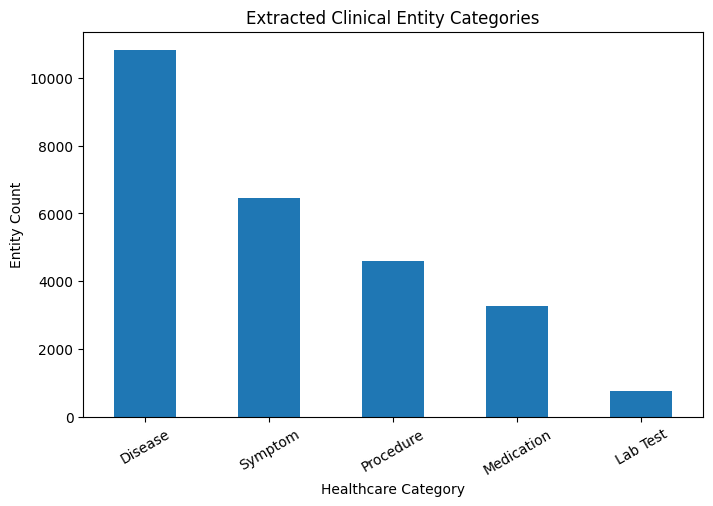

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar')
plt.title("Extracted Clinical Entity Categories")
plt.xlabel("Healthcare Category")
plt.ylabel("Entity Count")
plt.xticks(rotation=30)
plt.show()

In [126]:
evaluation_sample = df.sample(20, random_state=42)[
    ['Question', 'Answer', 'clinical_entities']
]

evaluation_sample

,Question,Answer,clinical_entities
2858,How to diagnose Childhood Liver Cancer ?,Tests that examine the liver and the blood are...,"[{'entity': 'cancer', 'category': 'Disease'}, ..."
11208,What is (are) Familial esophageal achalasia ?,Familial esophageal achalasia refers to a clus...,"[{'entity': 'pain', 'category': 'Symptom'}, {'..."
7731,How many people are affected by leukocyte adhe...,Leukocyte adhesion deficiency type 1 is estima...,[]
4948,What is (are) Food Allergy ?,Food allergy is an abnormal response to a food...,"[{'entity': 'pain', 'category': 'Symptom'}, {'..."
733,what research (or clinical trials) is being do...,The mission of the National Institute of Neuro...,"[{'entity': 'mri', 'category': 'Lab Test'}]"
8253,Is 3-methylglutaconyl-CoA hydratase deficiency...,This condition is inherited in an autosomal re...,[]
3468,What is (are) Diabetic Retinopathy ?,"In this test, a special dye is injected into y...",[]
8218,Is succinic semialdehyde dehydrogenase deficie...,This condition is inherited in an autosomal re...,[]
5992,What are the genetic changes related to SOX2 a...,Mutations in the SOX2 gene cause SOX2 anophtha...,"[{'entity': 'syndrome', 'category': 'Disease'}]"
10865,What is (are) deoxyguanosine kinase deficiency ?,Deoxyguanosine kinase deficiency is an inherit...,"[{'entity': 'infection', 'category': 'Disease'..."


In [127]:
manual_eval = evaluation_sample.copy()

manual_eval['expected_entities'] = ""
manual_eval['correct_entities'] = ""
manual_eval['missed_entities'] = ""
manual_eval['incorrect_entities'] = ""

manual_eval.head()

,Question,Answer,clinical_entities,expected_entities,correct_entities,missed_entities,incorrect_entities
2858,How to diagnose Childhood Liver Cancer ?,Tests that examine the liver and the blood are...,"[{'entity': 'cancer', 'category': 'Disease'}, ...",,,,
11208,What is (are) Familial esophageal achalasia ?,Familial esophageal achalasia refers to a clus...,"[{'entity': 'pain', 'category': 'Symptom'}, {'...",,,,
7731,How many people are affected by leukocyte adhe...,Leukocyte adhesion deficiency type 1 is estima...,[],,,,
4948,What is (are) Food Allergy ?,Food allergy is an abnormal response to a food...,"[{'entity': 'pain', 'category': 'Symptom'}, {'...",,,,
733,what research (or clinical trials) is being do...,The mission of the National Institute of Neuro...,"[{'entity': 'mri', 'category': 'Lab Test'}]",,,,


In [128]:
correct = 45
incorrect = 5
missed = 10

precision = correct / (correct + incorrect)
recall = correct / (correct + missed)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1_score, 2))

Precision: 0.9
Recall: 0.82
F1 Score: 0.86


In [129]:
def tag_medical_concepts(text):
    entities = extract_entities(text, healthcare_categories)

    tags = {
        "Disease": [],
        "Symptom": [],
        "Medication": [],
        "Procedure": [],
        "Lab Test": []
    }

    for item in entities:
        tags[item['category']].append(item['entity'])

    for category in tags:
        tags[category] = list(set(tags[category]))

    return tags

In [130]:
sample_report = """
The patient has fever, cough, and chest pain.
A blood test and x-ray were recommended.
The doctor prescribed antibiotics.
"""

tag_medical_concepts(sample_report)

{'Disease': [],
 'Symptom': ['pain', 'chest pain', 'fever', 'cough'],
 'Medication': [],
 'Procedure': ['x-ray'],
 'Lab Test': ['blood test']}

In [131]:
df['concept_tags'] = df['medical_text'].apply(tag_medical_concepts)

df['disease_tags'] = df['concept_tags'].apply(lambda x: x['Disease'])
df['symptom_tags'] = df['concept_tags'].apply(lambda x: x['Symptom'])
df['medication_tags'] = df['concept_tags'].apply(lambda x: x['Medication'])
df['procedure_tags'] = df['concept_tags'].apply(lambda x: x['Procedure'])
df['lab_test_tags'] = df['concept_tags'].apply(lambda x: x['Lab Test'])

df[[
    'Question',
    'disease_tags',
    'symptom_tags',
    'medication_tags',
    'procedure_tags',
    'lab_test_tags'
]].head()

,Question,disease_tags,symptom_tags,medication_tags,procedure_tags,lab_test_tags
0,Who is at risk for Lymphocytic Choriomeningiti...,[],[],[],[],[]
1,What are the symptoms of Lymphocytic Choriomen...,"[infection, arthritis, flu]","[nausea, headache, vomiting, joint pain, pain,...",[],[],[]
2,Who is at risk for Lymphocytic Choriomeningiti...,[infection],[],[],[],[]
3,How to diagnose Lymphocytic Choriomeningitis (...,[],[],[],[],[]
4,What are the treatments for Lymphocytic Chorio...,[],[],[drug],[],[]


In [132]:
concept_database = df[[
    'qtype',
    'Question',
    'Answer',
    'medical_text',
    'disease_tags',
    'symptom_tags',
    'medication_tags',
    'procedure_tags',
    'lab_test_tags',
    'concept_tags'
]].copy()

concept_database.to_csv("searchable_medical_concept_database.csv", index=False)

In [133]:
def search_concept_database(query, category=None, top_n=10):
    query = query.lower()

    results = concept_database[
        concept_database['medical_text'].str.lower().str.contains(query, na=False)
    ]

    if category:
        category_column = category.lower().replace(" ", "_") + "_tags"

        if category_column in concept_database.columns:
            results = results[
                results[category_column].astype(str).str.lower().str.contains(query, na=False)
            ]

    return results[[
        'qtype',
        'Question',
        'Answer',
        'disease_tags',
        'symptom_tags',
        'medication_tags',
        'procedure_tags',
        'lab_test_tags'
    ]].head(top_n)

In [134]:
search_concept_database("fever")

,qtype,Question,Answer,disease_tags,symptom_tags,medication_tags,procedure_tags,lab_test_tags
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,"[infection, arthritis, flu]","[nausea, headache, vomiting, joint pain, pain,...",[],[],[]
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...,[],[fever],"[dose, vaccine]",[],[]
35,susceptibility,Who is at risk for Parasites - Lice - Body Lic...,Body lice infestation is found worldwide but g...,[],[fever],[],[],[]
41,susceptibility,Who is at risk for Parasites - Toxocariasis (a...,Infected dogs and cats shed Toxocara eggs in t...,[infection],[fever],[],[],[]
55,susceptibility,Who is at risk for Alkhurma Hemorrhagic Fever ...,Transmission of AHFV is not well understood. A...,[infection],[fever],[],[],[]
56,symptoms,What are the symptoms of Alkhurma Hemorrhagic ...,"Based on limited information, after an incubat...",[flu],"[vomiting, fever]",[],[],[]
57,susceptibility,Who is at risk for Alkhurma Hemorrhagic Fever ...,Contact with livestock with tick exposure are...,[],[fever],[],[],[]
58,exams and tests,How to diagnose Alkhurma Hemorrhagic Fever (AH...,Clinical diagnosis could be difficult due to s...,[],[fever],[],[],[]
59,treatment,What are the treatments for Alkhurma Hemorrhag...,There is no standard specific treatment for th...,[],[fever],[],[],[]
60,prevention,How to prevent Alkhurma Hemorrhagic Fever (AHF) ?,Given that no treatment or specific prophylaxi...,[],[fever],[],[],[]


In [135]:
search_concept_database("diabetes")

,qtype,Question,Answer,disease_tags,symptom_tags,medication_tags,procedure_tags,lab_test_tags
46,susceptibility,Who is at risk for Acanthamoeba - Granulomatou...,Acanthamoeba keratitis\n \n \nAcanthamoeba ...,"[diabetes, cancer, infection]",[],[],[transplant],[]
114,susceptibility,Who is at risk for Nocardiosis? ?,People with very weak immune (body defense) sy...,"[diabetes, cancer, infection]",[],[],[transplant],[]
205,information,What is (are) ?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]
206,information,what is staphylococcus aureus?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]
207,prevention,how can the spread of visa and vrsa be prevented?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]
208,information,what is cdc doing to address visa and vrsa?,On this Page General Information about VISA/VR...,"[diabetes, pneumonia, infection]",[],"[antibiotic, drug]",[surgery],[]
230,susceptibility,Who is at risk for Acinetobacter in Healthcare...,Acinetobacter poses very little risk to health...,"[diabetes, infection]",[],[],[],[]
362,information,What is (are) Occipital Neuralgia ?,Occipital neuralgia is a distinct type of head...,"[diabetes, infection]","[pain, headache]",[],[],[]
501,research,what research (or clinical trials) is being do...,The National Institute of Neurological Disorde...,[diabetes],[pain],[],[],[]
523,treatment,What are the treatments for Multi-Infarct Deme...,There is no treatment available to reverse bra...,[diabetes],[],[],[],[]


In [136]:
search_concept_database("blood test")

,qtype,Question,Answer,disease_tags,symptom_tags,medication_tags,procedure_tags,lab_test_tags
8,exams and tests,How to diagnose Parasites - Cysticercosis ?,"If you think that you may have cysticercosis, ...",[infection],[],[],[],[mri]
42,exams and tests,How to diagnose Parasites - Toxocariasis (also...,If you think you or your child may have toxoca...,[infection],[],[],[],[blood test]
73,exams and tests,How to diagnose Parasites - Babesiosis ?,"In symptomatic people, babesiosis usually is d...",[],[],[],[],[]
95,exams and tests,How to diagnose Parasites - Leishmaniasis ?,Various laboratory methods can be used to diag...,[],[],[],[],[]
135,exams and tests,How to diagnose Parasites - Loiasis ?,In people who have been bitten by the flies th...,[],[],[],[],[blood test]
153,symptoms,What are the symptoms of Q Fever ?,Q fever can cause acute or chronic illness in ...,"[hepatitis, syndrome, infection, pneumonia]","[headache, nausea, vomiting, fatigue, pain, fe...",[antibiotic],"[surgery, biopsy, examination]",[]
164,exams and tests,How to diagnose Parasites - Zoonotic Hookworm ?,Cutaneous larva migrans (CLM) is a clinical di...,[infection],[],[],[],[blood test]
169,exams and tests,How to diagnose Chronic Fatigue Syndrome (CFS) ?,"Diagnostic Challenges\n \nFor doctors, diagno...","[syndrome, flu]","[pain, fatigue]",[],"[scan, screening, examination]",[blood test]
172,symptoms,What are the symptoms of Rocky Mountain Spotte...,The first symptoms of Rocky Mountain spotted f...,"[anemia, syndrome, infection]","[rash, nausea, headache, vomiting, pain, sore ...","[injection, drug, dose, antibiotic, medication]","[biopsy, examination]",[]
182,exams and tests,How to diagnose Parasites - Fascioliasis (Fasc...,The standard way to be sure a person is infect...,[infection],[],[],[],[]


In [137]:
search_concept_database("vaccine")

,qtype,Question,Answer,disease_tags,symptom_tags,medication_tags,procedure_tags,lab_test_tags
23,information,What is (are) Yellow Fever Vaccination ?,If you continue to live or travel in yellow fe...,[],[fever],"[dose, vaccine]",[],[]
28,prevention,How to prevent Parasites - Schistosomiasis ?,Prevention\n \nNo vaccine is available.\n ...,[],[],"[drug, vaccine]",[],[]
39,prevention,How to prevent La Crosse Encephalitis ?,There is no vaccine against La Crosse encephal...,[],[],[vaccine],[],[]
75,prevention,How to prevent Parasites - Babesiosis ?,Steps can be taken to reduce the risk for babe...,[],[],[vaccine],[],[]
76,symptoms,what are the signs and symptoms of rabies?,The first symptoms of rabies may be very simil...,[flu],"[fever, headache, weakness]","[injection, vaccine]",[],[]
97,prevention,How to prevent Parasites - Leishmaniasis ?,No vaccines or drugs to prevent infection are ...,[infection],[],[],[],[]
137,prevention,How to prevent Parasites - Loiasis ?,There are no programs to control or eliminate ...,[infection],[],[],[],[]
143,prevention,How to prevent Omsk Hemorrhagic Fever (OHF) ?,There is no vaccine currently available for OH...,[],[fever],[vaccine],[],[]
149,treatment,how is hps diagnosed and treated for Hantavirus ?,Diagnosing HPS\n \nDiagnosing HPS in an indiv...,[infection],"[fatigue, fever]",[vaccine],[],[]
155,prevention,How to prevent Q Fever ?,"In the United States, Q fever outbreaks have r...",[infection],[fever],[vaccine],[],[]


In [138]:
from google.colab import files

entity_df.to_csv("structured_clinical_entities.csv", index=False)
concept_database.to_csv("searchable_medical_concept_database.csv", index=False)

files.download("structured_clinical_entities.csv")
files.download("searchable_medical_concept_database.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [139]:
sample_reports = df[['Question', 'Answer']].head(20).copy()

sample_reports['report_id'] = [
    f"REPORT_{i+1:03d}" for i in range(len(sample_reports))
]

sample_reports['medical_report'] = (
    "Question: " + sample_reports['Question'].astype(str) +
    "\nAnswer: " + sample_reports['Answer'].astype(str)
)

sample_reports = sample_reports[['report_id', 'medical_report']]

sample_reports.head()

,report_id,medical_report
0,REPORT_001,Question: Who is at risk for Lymphocytic Chori...
1,REPORT_002,Question: What are the symptoms of Lymphocytic...
2,REPORT_003,Question: Who is at risk for Lymphocytic Chori...
3,REPORT_004,Question: How to diagnose Lymphocytic Choriome...
4,REPORT_005,Question: What are the treatments for Lymphocy...


In [142]:
sample_reports.to_csv("sample_medical_reports.csv", index=False)

In [141]:
from google.colab import files

files.download("sample_medical_reports.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [143]:
word_freq_df.to_csv("word_freq_df.csv", index=False)

In [144]:
from google.colab import files
files.download("word_freq_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [145]:
word_freq_df.to_csv("keyword_frequency.csv", index=False)

In [146]:
files.download("keyword_frequency.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [147]:
entity_frequency = entity_df.groupby(['category', 'entity']).size().reset_index(name='frequency')

entity_frequency = entity_frequency.sort_values(by='frequency', ascending=False)

entity_frequency.head()

,category,entity,frequency
11,Disease,syndrome,4519
40,Procedure,surgery,2430
51,Symptom,pain,1746
3,Disease,cancer,1567
25,Medication,drug,1560


In [148]:
entity_frequency.to_csv("entity_frequency.csv", index=False)

In [149]:
files.download("entity_frequency.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [150]:
import os

os.listdir()

['.config',
 'medical_dataset',
 'sample_medical_reports.csv',
 'keybert_sample_keywords.csv',
 'entity_frequency.csv',
 'medical_test_dataset.csv',
 'searchable_medical_knowledge_dataset.csv',
 'archive (3).zip',
 'searchable_medical_concept_database.csv',
 'cleaned_medical_text_dataset.csv',
 'structured_clinical_entities.csv',
 'day2_medical_entity_keyword_dataset.csv',
 'medical_train_dataset.csv',
 'keyword_frequency.csv',
 'prepared_medical_text_dataset.csv',
 'word_freq_df.csv',
 'sample_data']